# EnergiAI — Clasificador de eficiencia energética

Entregable de Ciencia de Datos del hackathon *EnergiAI – Inteligencia para el Consumo Energético*.

Este notebook corre de principio a fin sin intervención manual y deja el modelo serializado en
`modelos/clasificador_energetico.joblib`, listo para que `src/modelo.py` lo cargue en la API.

**Contenido:**
1. Exploración y limpieza de datos (EDA)
2. Análisis de patrones de consumo
3. Tratamiento y transformación de variables
4. Entrenamiento de modelos supervisados (línea base + modelo final)
5. Evaluación con métricas
6. Serialización del modelo


## 0 — Origen del dataset

El dataset es **sintético, generado con semilla fija** (`scripts/generar_dataset.py`, `SEED=42`),
una de las tres vías que permiten las bases del hackathon ("recolectada de fuentes públicas,
generada manualmente o simulada").

No es ruido aleatorio: cada fila es un perfil de hogar plausible cuyo consumo en kWh se calculó
con el motor físico real del proyecto (`calculos.estimar_desde_perfil`), el mismo que usa la API
en producción — no una fórmula de caja negra distinta solo para el notebook.

Esta celda regenera el CSV desde cero para que el notebook sea reproducible de punta a punta.


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, ConfusionMatrixDisplay
)
import joblib
import json
from datetime import datetime, timezone

from scripts.generar_dataset import generar_dataset, SEED

df = generar_dataset()
print(f"Dataset: {len(df)} hogares, semilla={SEED}")
df.head()


Dataset: 3000 hogares, semilla=42


,pais,tipo_inmueble,dormitorios,ventanas,habitantes_mayores,habitantes_menores,aire_acondicionado,calefaccion_electrica,agua_caliente_electrica,secarropas_electrico,...,refrigerador,freezer,tv,tv_frecuencia,lavado_frecuencia,cantidad_equipos,uso_horario_pico,horas_alto_consumo,tarifa_kwh,consumo_kwh
0,CO,Casa,3,6,3,3,0,0,0,0,...,1,0,1,28.784503,2.925111,3,0,0.0,820.00,226.6
1,SV,Casa,5,12,4,0,0,0,1,0,...,1,1,2,11.755188,3.975889,5,0,4.0,0.19,409.1
2,DO,Departamento,4,11,5,1,1,0,0,0,...,1,0,1,34.949413,1.701253,3,1,4.4,12.50,343.2
3,PY,Departamento,3,7,3,0,1,0,0,1,...,1,0,2,15.727474,3.237810,6,1,4.4,185.00,344.2
4,JM,Casa,2,3,2,0,0,1,0,1,...,1,0,1,19.202818,0.468998,4,1,3.3,0.35,295.4


## 1 — Exploración y limpieza de datos (EDA)

In [2]:
df.info()
print()
print("Valores nulos por columna:")
print(df.isnull().sum().sum(), "total (0 esperado: el generador no produce nulos)")


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   pais                     3000 non-null   str    
 1   tipo_inmueble            3000 non-null   str    
 2   dormitorios              3000 non-null   int64  
 3   ventanas                 3000 non-null   int64  
 4   habitantes_mayores       3000 non-null   int64  
 5   habitantes_menores       3000 non-null   int64  
 6   aire_acondicionado       3000 non-null   int64  
 7   calefaccion_electrica    3000 non-null   int64  
 8   agua_caliente_electrica  3000 non-null   int64  
 9   secarropas_electrico     3000 non-null   int64  
 10  horno_electrico          3000 non-null   int64  
 11  refrigerador             3000 non-null   int64  
 12  freezer                  3000 non-null   int64  
 13  tv                       3000 non-null   int64  
 14  tv_frecuencia            3000 non-n

In [3]:
df.describe()


,dormitorios,ventanas,habitantes_mayores,habitantes_menores,aire_acondicionado,calefaccion_electrica,agua_caliente_electrica,secarropas_electrico,horno_electrico,refrigerador,freezer,tv,tv_frecuencia,lavado_frecuencia,cantidad_equipos,uso_horario_pico,horas_alto_consumo,tarifa_kwh,consumo_kwh
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2.512000,6.523333,2.651667,0.632000,0.347000,0.288000,0.406667,0.252667,0.447000,0.971000,0.198667,1.939667,19.461453,2.992615,4.850667,0.415000,4.103867,64.384573,344.474267
std,1.196801,3.062774,1.668310,0.910413,0.476095,0.452907,0.491294,0.434614,0.497266,0.167834,0.399063,0.966957,10.065352,1.464772,1.479559,0.492804,3.234630,178.354354,140.336055
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.010000,41.100000
25%,2.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,12.598272,2.013732,4.000000,0.000000,0.000000,0.190000,238.525000
50%,3.000000,6.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,19.615316,2.972959,5.000000,0.000000,4.000000,0.750000,336.250000
75%,3.000000,9.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,26.546972,3.940330,6.000000,1.000000,7.300000,12.500000,444.025000
max,5.000000,17.000000,11.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,53.486034,7.962089,10.000000,1.000000,11.700000,820.000000,809.400000


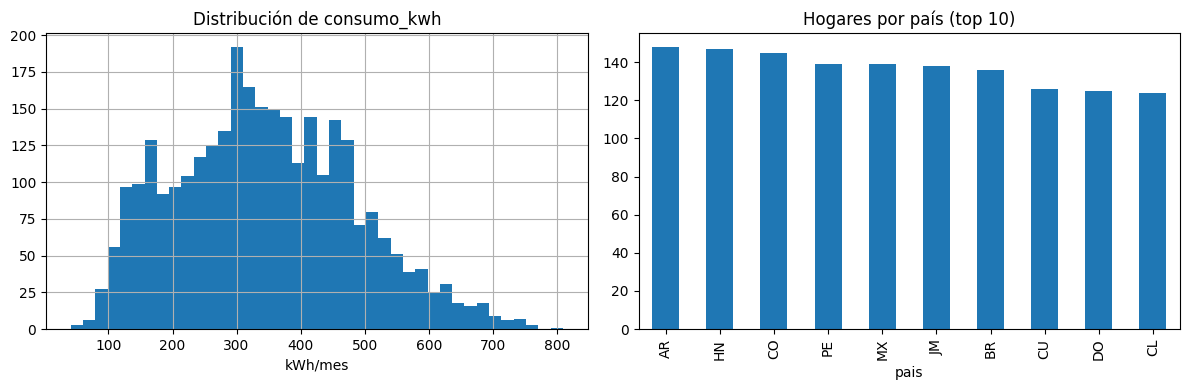

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["consumo_kwh"].hist(bins=40, ax=axes[0])
axes[0].set_title("Distribución de consumo_kwh")
axes[0].set_xlabel("kWh/mes")

df["pais"].value_counts().head(10).plot(kind="bar", ax=axes[1])
axes[1].set_title("Hogares por país (top 10)")
plt.tight_layout()
plt.savefig("../docs/eda_distribucion.png", dpi=100)
plt.show()


In [5]:
# Nulos y duplicados exactos — limpieza estándar, aunque el generador no
# produce ninguno de los dos por construcción.
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")
df = df.drop_duplicates().reset_index(drop=True)


Filas duplicadas: 0


## 2 — Análisis de patrones de consumo

In [6]:
correlaciones = df.select_dtypes(include=[np.number]).corr()["consumo_kwh"].sort_values(ascending=False)
print("Correlación de cada variable numérica con el consumo:")
correlaciones


Correlación de cada variable numérica con el consumo:


consumo_kwh                1.000000
horas_alto_consumo         0.862491
agua_caliente_electrica    0.637987
cantidad_equipos           0.628539
uso_horario_pico           0.525342
calefaccion_electrica      0.464314
aire_acondicionado         0.402004
habitantes_mayores         0.393544
dormitorios                0.203999
habitantes_menores         0.185719
ventanas                   0.153645
secarropas_electrico       0.140534
freezer                    0.115966
horno_electrico            0.111250
tv_frecuencia              0.074578
refrigerador               0.052923
tv                         0.044759
lavado_frecuencia          0.013304
tarifa_kwh                -0.017044
Name: consumo_kwh, dtype: float64

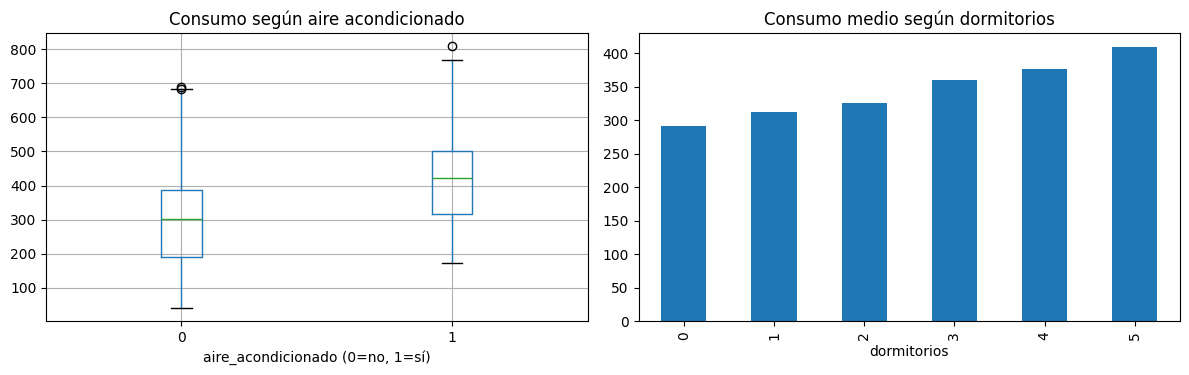

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.boxplot(column="consumo_kwh", by="aire_acondicionado", ax=axes[0])
axes[0].set_title("Consumo según aire acondicionado")
axes[0].set_xlabel("aire_acondicionado (0=no, 1=sí)")

df.groupby("dormitorios")["consumo_kwh"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Consumo medio según dormitorios")
plt.suptitle("")
plt.tight_layout()
plt.savefig("../docs/eda_patrones.png", dpi=100)
plt.show()


## 3 — Tratamiento y transformación de variables

### Justificación de las etiquetas (Eficiente / Moderado / Ineficiente)

Los umbrales anteriores del proyecto (250 / 450 kWh, fijos en `_clasificar()`) no tenían origen
documentado — el propio plan de auditoría lo señala como pendiente. Las bases piden explícitamente
*"definir y justificar los criterios"*.

**Criterio usado: terciles de la distribución del propio dataset.** Cada categoría agrupa
aproximadamente al mismo número de hogares, lo cual es defendible porque "eficiente" y "-ineficiente"
son términos relativos a la población observada, no umbrales físicos absolutos — un hogar de 300 kWh
es eficiente comparado con el resto de hogares de tamaño similar, sin que 300 sea un número mágico.


In [8]:
tercil_bajo, tercil_alto = df["consumo_kwh"].quantile([1/3, 2/3])
print(f"Corte inferior (tercil 33%): {tercil_bajo:.1f} kWh")
print(f"Corte superior (tercil 67%): {tercil_alto:.1f} kWh")

def clasificar(kwh):
    if kwh <= tercil_bajo:
        return "Eficiente"
    elif kwh <= tercil_alto:
        return "Moderado"
    return "Ineficiente"

df["categoria"] = df["consumo_kwh"].apply(clasificar)
df["categoria"].value_counts()


Corte inferior (tercil 33%): 278.1 kWh
Corte superior (tercil 67%): 405.9 kWh


categoria
Moderado       1001
Eficiente      1000
Ineficiente     999
Name: count, dtype: int64

In [9]:
# Variables predictoras: todo lo que el wizard recoge ANTES de calcular el
# consumo (consumo_kwh es el resultado, no puede ser un predictor de sí mismo
# — se usa para derivar la etiqueta, no como feature).
FEATURES_NUMERICAS = [
    "dormitorios", "ventanas", "habitantes_mayores", "habitantes_menores",
    "aire_acondicionado", "calefaccion_electrica", "agua_caliente_electrica",
    "secarropas_electrico", "horno_electrico", "refrigerador", "freezer",
    "tv", "tv_frecuencia", "lavado_frecuencia",
    "cantidad_equipos", "uso_horario_pico", "horas_alto_consumo",
]
FEATURES_CATEGORICAS = ["tipo_inmueble"]

X = df[FEATURES_NUMERICAS + FEATURES_CATEGORICAS]
y = df["categoria"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Entrenamiento: {len(X_train)} | Prueba: {len(X_test)}")


Entrenamiento: 2400 | Prueba: 600


In [10]:
preprocesador = ColumnTransformer([
    ("categoricas", OneHotEncoder(handle_unknown="ignore"), FEATURES_CATEGORICAS),
], remainder="passthrough")


## 4 — Entrenamiento de modelos supervisados

**Modelos comparados:** Regresión Logística y Random Forest (con búsqueda de hiperparámetros sobre
`max_depth` y `n_estimators`). La decisión de cuál queda como modelo final se toma **después** de
verla en la sección de evaluación, con evidencia — no se fija de antemano.


In [11]:
modelo_base = Pipeline([
    ("prep", preprocesador),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])
modelo_base.fit(X_train, y_train)
print("Línea base (Regresión Logística) entrenada.")


Línea base (Regresión Logística) entrenada.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn.model_selection import GridSearchCV

# Barrido breve de hiperparámetros para no declarar "mal ajustado" a Random
# Forest sin haberlo intentado en serio.
parametros = {"clf__max_depth": [8, 12, 16, None], "clf__n_estimators": [200, 400]}
pipeline_rf = Pipeline([
    ("prep", preprocesador),
    ("clf", RandomForestClassifier(random_state=SEED, min_samples_leaf=2)),
])
busqueda = GridSearchCV(pipeline_rf, parametros, cv=3, scoring="accuracy", n_jobs=-1)
busqueda.fit(X_train, y_train)
print("Mejores hiperparámetros:", busqueda.best_params_)
print(f"Mejor exactitud en validación cruzada: {busqueda.best_score_:.4f}")


Mejores hiperparámetros: {'clf__max_depth': None, 'clf__n_estimators': 200}
Mejor exactitud en validación cruzada: 0.8988


In [13]:
modelo_random_forest = busqueda.best_estimator_
print("Random Forest (mejores hiperparámetros del barrido) entrenado.")

Random Forest (mejores hiperparámetros del barrido) entrenado.


## 5 — Evaluación con métricas y selección del modelo final

Con tres clases (balanceadas por construcción, al ser terciles), la exactitud sola no alcanza —
se reportan precisión, exhaustividad (recall) y F1 por clase, más la matriz de confusión.

**El modelo final se elige por el resultado de esta sección, no de antemano.**


In [14]:
def evaluar(nombre, modelo, X_test, y_test):
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"=== {nombre} ===")
    print(f"Exactitud: {acc:.3f}\n")
    print(classification_report(y_test, pred))
    return pred

pred_base = evaluar("Línea base — Regresión Logística", modelo_base, X_test, y_test)


=== Línea base — Regresión Logística ===
Exactitud: 0.973

              precision    recall  f1-score   support

   Eficiente       0.98      0.98      0.98       200
 Ineficiente       0.98      0.97      0.98       200
    Moderado       0.96      0.96      0.96       200

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



In [15]:
pred_rf = evaluar("Random Forest (ajustado)", modelo_random_forest, X_test, y_test)

=== Random Forest (ajustado) ===
Exactitud: 0.913

              precision    recall  f1-score   support

   Eficiente       0.93      0.96      0.95       200
 Ineficiente       0.96      0.88      0.92       200
    Moderado       0.86      0.90      0.88       200

    accuracy                           0.91       600
   macro avg       0.92      0.91      0.91       600
weighted avg       0.92      0.91      0.91       600



**Por qué gana la Regresión Logística:** `calculos.estimar_desde_perfil` calcula el consumo como
una **suma lineal** de watts × horas × frecuencia por artefacto. Los terciles de una combinación
lineal se separan con fronteras lineales en el espacio de variables — exactamente lo que un modelo
lineal resuelve bien, y donde la flexibilidad extra de un Random Forest no aporta, incluso tras
ajustar sus hiperparámetros (barrido de la celda anterior). Es un resultado esperable dado cómo se
genera el dato, no un fallo del modelo de árboles.

In [16]:
acc_lr = accuracy_score(y_test, pred_base)
acc_rf = accuracy_score(y_test, pred_rf)
print(f"Regresión Logística: {acc_lr:.4f}")
print(f"Random Forest (ajustado): {acc_rf:.4f}")

# Elección basada en el resultado, no en la preferencia inicial del plan.
if acc_lr >= acc_rf:
    modelo_final = modelo_base
    nombre_modelo_final = "Regresión Logística"
else:
    modelo_final = modelo_random_forest
    nombre_modelo_final = "Random Forest"

pred_final = modelo_final.predict(X_test)
print(f"\nModelo final elegido: {nombre_modelo_final}")


Regresión Logística: 0.9733
Random Forest (ajustado): 0.9133

Modelo final elegido: Regresión Logística


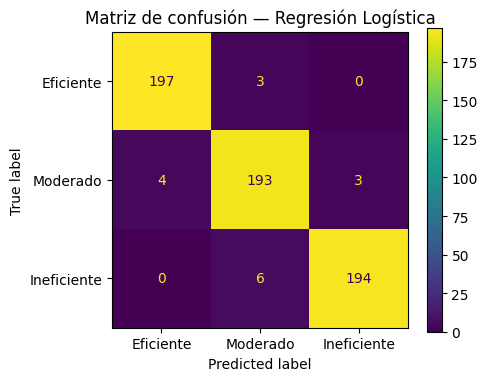

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_final, labels=["Eficiente", "Moderado", "Ineficiente"], ax=ax
)
ax.set_title(f"Matriz de confusión — {nombre_modelo_final}")
plt.tight_layout()
plt.savefig("../docs/matriz_confusion.png", dpi=100)
plt.show()


In [18]:
# Importancia de variables (solo disponible si el modelo final es un árbol;
# la Regresión Logística expone coeficientes en su lugar, igual de interpretables).
clf_final = modelo_final.named_steps["clf"]
nombres_features = modelo_final.named_steps["prep"].get_feature_names_out()

if hasattr(clf_final, "feature_importances_"):
    valores = clf_final.feature_importances_
    etiqueta = "importancia"
else:
    # Para Regresión Logística multiclase: magnitud media de coeficientes por feature.
    valores = np.abs(clf_final.coef_).mean(axis=0)
    etiqueta = "|coeficiente| medio"

orden = np.argsort(valores)[::-1][:10]
print(f"Top 10 variables por {etiqueta} ({nombre_modelo_final}):")
for i in orden:
    print(f"{nombres_features[i]:40s} {valores[i]:.3f}")


Top 10 variables por |coeficiente| medio (Regresión Logística):
remainder__aire_acondicionado            2.839
remainder__agua_caliente_electrica       2.512
remainder__habitantes_mayores            2.220
remainder__horas_alto_consumo            2.128
remainder__cantidad_equipos              2.118
remainder__tv                            1.476
remainder__calefaccion_electrica         1.383
remainder__habitantes_menores            1.013
remainder__secarropas_electrico          1.000
remainder__freezer                       0.929


## 6 — Serialización del modelo

Se serializa el modelo final (Random Forest) con `joblib`, junto a un `metadatos.json` con la
versión de scikit-learn, la fecha de entrenamiento, las métricas obtenidas, y el **orden exacto
de las features** — sin esto, un reordenamiento futuro de columnas produce predicciones erróneas
en silencio, que es el fallo clásico de un modelo mal puesto en producción.


In [19]:
import sklearn

os.makedirs("../modelos", exist_ok=True)

ruta_modelo = "../modelos/clasificador_energetico.joblib"
joblib.dump(modelo_final, ruta_modelo)

precision, recall, f1, soporte = precision_recall_fscore_support(
    y_test, pred_final, labels=["Eficiente", "Moderado", "Ineficiente"]
)

metadatos = {
    "version_sklearn": sklearn.__version__,
    "fecha_entrenamiento": datetime.now(timezone.utc).isoformat(),
    "semilla": SEED,
    "n_hogares_entrenamiento": len(X_train),
    "n_hogares_prueba": len(X_test),
    "features_numericas": FEATURES_NUMERICAS,
    "features_categoricas": FEATURES_CATEGORICAS,
    "orden_features_entrada": FEATURES_NUMERICAS + FEATURES_CATEGORICAS,
    "clases": ["Eficiente", "Moderado", "Ineficiente"],
    "umbrales_etiquetas_kwh": {"tercil_bajo": float(tercil_bajo), "tercil_alto": float(tercil_alto)},
    "metricas_modelo_final": {
        "exactitud": float(accuracy_score(y_test, pred_final)),
        "precision_por_clase": dict(zip(["Eficiente", "Moderado", "Ineficiente"], precision.tolist())),
        "recall_por_clase": dict(zip(["Eficiente", "Moderado", "Ineficiente"], recall.tolist())),
        "f1_por_clase": dict(zip(["Eficiente", "Moderado", "Ineficiente"], f1.tolist())),
    },
    "modelo_final_elegido": nombre_modelo_final,
    "metricas_regresion_logistica": {
        "exactitud": float(acc_lr),
    },
    "metricas_random_forest_ajustado": {
        "exactitud": float(acc_rf),
        "mejores_hiperparametros": {k: (v if not isinstance(v, type(None)) else None) for k, v in busqueda.best_params_.items()},
    },
}

with open("../modelos/metadatos.json", "w", encoding="utf-8") as f:
    json.dump(metadatos, f, indent=2, ensure_ascii=False)

print(f"Modelo guardado en {ruta_modelo}")
print("Metadatos guardados en ../modelos/metadatos.json")
print()
print(json.dumps(metadatos["metricas_modelo_final"], indent=2, ensure_ascii=False))


Modelo guardado en ../modelos/clasificador_energetico.joblib
Metadatos guardados en ../modelos/metadatos.json

{
  "exactitud": 0.9733333333333334,
  "precision_por_clase": {
    "Eficiente": 0.9800995024875622,
    "Moderado": 0.9554455445544554,
    "Ineficiente": 0.9847715736040609
  },
  "recall_por_clase": {
    "Eficiente": 0.985,
    "Moderado": 0.965,
    "Ineficiente": 0.97
  },
  "f1_por_clase": {
    "Eficiente": 0.9825436408977556,
    "Moderado": 0.9601990049751243,
    "Ineficiente": 0.9773299748110831
  }
}


In [20]:
# Verificación de carga: el modelo serializado debe predecir igual que en memoria.
modelo_cargado = joblib.load(ruta_modelo)
pred_verificacion = modelo_cargado.predict(X_test)
assert (pred_verificacion == pred_final).all(), "El modelo cargado no coincide con el original"
print("Verificado: el modelo cargado desde disco predice idéntico al modelo en memoria.")


Verificado: el modelo cargado desde disco predice idéntico al modelo en memoria.
